<a href="https://colab.research.google.com/github/logolag-original/logolag-original/blob/Algebra-curso/unidad_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cuadratic**


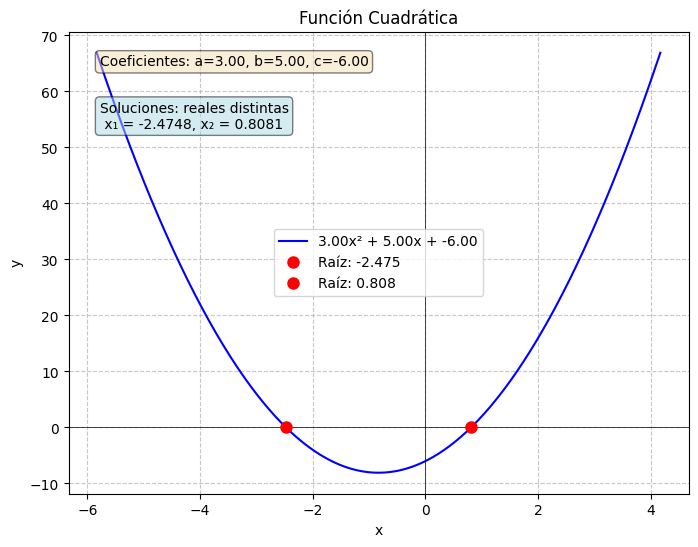

Coeficientes: a=3.00, b=5.00, c=-6.00
Soluciones: reales distintas
 x₁ = -2.4748, x₂ = 0.8081


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def dibujar_cuadratica(a, b, c):
    """
    Dibuja la función cuadrática f(x) = a*x^2 + b*x + c,
    muestra sus coeficientes y calcula las soluciones (raíces).

    Parámetros:
    a, b, c (float): coeficientes de la cuadrática.
    """
    # Crear un rango de valores x para el gráfico
    # Elegimos un rango alrededor del vértice para una mejor visualización
    # El vértice está en x = -b/(2a) si a != 0
    if a != 0:
        vertice_x = -b / (2*a)
        # Rango desde vértice - 5 hasta vértice + 5, asegurando al menos 10 unidades de ancho
        x_min = vertice_x - 5
        x_max = vertice_x + 5
    else:
        # Si a=0 no es cuadrática pero podría ser lineal; manejamos ese caso
        x_min = -10
        x_max = 10

    # Generamos 400 puntos para una curva suave
    x = np.linspace(x_min, x_max, 400)
    y = a*x**2 + b*x + c

    # Calcular el discriminante
    discriminante = b**2 - 4*a*c

    # Calcular soluciones
    if a == 0:
        # Caso lineal: bx + c = 0 => x = -c/b si b != 0
        if b != 0:
            raiz = -c / b
            soluciones = [raiz]
            tipo = "lineal (una raíz)"
        else:
            if c == 0:
                soluciones = "todos los reales (identidad)"
                tipo = "identidad"
            else:
                soluciones = "ninguna (contradicción)"
                tipo = "contradicción"
    else:
        if discriminante > 0:
            raiz1 = (-b + math.sqrt(discriminante)) / (2*a)
            raiz2 = (-b - math.sqrt(discriminante)) / (2*a)
            soluciones = sorted([raiz1, raiz2])
            tipo = "reales distintas"
        elif discriminante == 0:
            raiz = -b / (2*a)
            soluciones = [raiz]
            tipo = "reales doble"
        else:
            parte_real = -b / (2*a)
            parte_imag = math.sqrt(-discriminante) / (2*a)
            soluciones = (complex(parte_real, parte_imag), complex(parte_real, -parte_imag))
            tipo = "complejas conjugadas"

    # Crear la figura y el gráfico
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label=f'{a:.2f}x² + {b:.2f}x + {c:.2f}', color='blue')
    plt.axhline(0, color='black', linewidth=0.5)  # Eje x
    plt.axvline(0, color='black', linewidth=0.5)  # Eje y
    plt.grid(True, linestyle='--', alpha=0.7)

    # Marcar las raíces en el gráfico (si son reales)
    if a != 0 and discriminante >= 0:
        for raiz in soluciones:
            if isinstance(raiz, (int, float)):
                plt.plot(raiz, 0, 'ro', markersize=8, label=f'Raíz: {raiz:.3f}' if 'Raíz' not in plt.gca().get_legend_handles_labels()[1] else "")

    # Añadir texto con coeficientes y soluciones
    texto_coef = f'Coeficientes: a={a:.2f}, b={b:.2f}, c={c:.2f}'
    texto_sol = f'Soluciones: {tipo}'
    if a != 0:
        if discriminante >= 0:
            if len(soluciones) == 2:
                texto_sol += f'\n x₁ = {soluciones[0]:.4f}, x₂ = {soluciones[1]:.4f}'
            else:
                texto_sol += f'\n x = {soluciones[0]:.4f}'
        else:
            texto_sol += f'\n {soluciones[0]:.4f} y {soluciones[1]:.4f}'
    elif a == 0 and b != 0:
        texto_sol += f'\n x = {soluciones[0]:.4f}'
    elif a == 0 and b == 0 and c == 0:
        texto_sol += '\n Infinitas soluciones (0=0)'
    elif a == 0 and b == 0 and c != 0:
        texto_sol += '\n Sin solución'

    plt.title('Función Cuadrática')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

    # Mostrar texto en el gráfico
    plt.text(0.05, 0.95, texto_coef, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.text(0.05, 0.85, texto_sol, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.show()

    # También imprimir en consola
    print(texto_coef)
    print(texto_sol)

# Ejemplo de uso
if __name__ == "__main__":
    # Prueba con una cuadrática con raíces reales
    dibujar_cuadratica(3, 5, -6)   # 3x^2 + 5x -6

**Newton's method**

---



In [ ]:
import math
import numpy as np
#2x^5-3/4x^4+3x^2+3

a=1
b=1
c=0
d= -1
#e=0
#f=-1
#define Newton's method
def NewtonMethod(x0, tol, N, fun, dfun ):
    print('\n\n*** NEWTON ITERATION ***')
    steps = 1
    flag = 1
    condition = True
    while condition:
        x1 = x0 - fun(x0)/dfun(x0) # update x
        e = abs(x1 - x0) # define the error
        print('Iteration-%d, x1 = %0.6f, error = %0.6f ' % (steps, x1,e))
        steps = steps + 1 #increment steps
        if steps>N:
            flag=0
            break
        if e < tol : #check for convergence
            break
        x0 = x1 #update x0 for next iteration
    if flag==1:
        print('\nRoot is: %0.8f' % x1)
        return x1 # Return the found root
    else:
        print('\nNot Convergent.')
        return None # Return None if not convergent

#define your function
def fun(x):
    return a*x**3 + b*x**2+c*x+d

def dfun(x):
    return 3*a*x**2 + b*2*x+c

#solution
newton_root = NewtonMethod(2, 0.0001, 20, fun, dfun)



*** NEWTON ITERATION ***
Iteration-1, x1 = 1.312500, error = 0.687500 
Iteration-2, x1 = 0.929637, error = 0.382863 
Iteration-3, x1 = 0.779671, error = 0.149966 
Iteration-4, x1 = 0.755480, error = 0.024191 
Iteration-5, x1 = 0.754878, error = 0.000602 
Iteration-6, x1 = 0.754878, error = 0.000000 

Root is: 0.75487767


Graphic solution

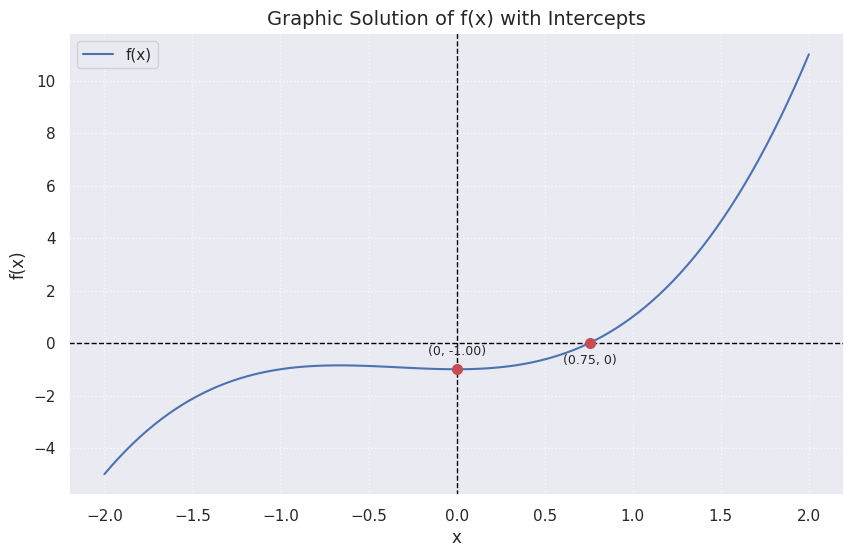

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns #We import Seaborn which is a nice toolbox for data plotting
sns.set()
fig = plt.figure(figsize=(10, 6)) # Make figure slightly larger for better readability
ax = plt.axes()

x = np.linspace(-2, 2, 100)
ax.plot(x, fun(x), label='f(x)')

# Highlight x and y axes
ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
ax.axvline(0, color='black', linewidth=1.0, linestyle='--')

# Y-intercept
y_intercept_val = fun(0)
ax.plot(0, y_intercept_val, 'ro', markersize=7) # Mark the point
ax.annotate(f'(0, {y_intercept_val:.2f})', (0, y_intercept_val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# X-intercept (from Newton's method)
# Ensure 'newton_root' is available from the previous cell's execution
if 'newton_root' in globals() and newton_root is not None:
    ax.plot(newton_root, 0, 'ro', markersize=7) # Mark the point
    ax.annotate(f'({newton_root:.2f}, 0)', (newton_root, 0), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
else:
    print("Newton's method root not found or not convergent. Cannot mark x-intercept.")


ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title("Graphic Solution of f(x) with Intercepts", fontsize=14)
ax.grid(True, linestyle=':', alpha=0.7) # Add a finer grid
ax.legend()
plt.show() # Display the plot

**Fixed Point method**

In [ ]:
import math
import numpy as np


h=2
j=-3
k=1
l=-1


def fixedPoint(x0, tol, N, fun, fun2):
    print('\n\n*** FIXED POINT ITERATION ***')
    step = 1 # initialization
    flag = 1 # flag for convegence
    condition = True
    while condition:
        x1 = fun2(x0) # complete: x1 = g(x0)
        print('Iteration-%d, x1 = %0.6f, error = %0.6f ' % (step, x1,abs(fun(x1))))
        x0 = x1 # complete: update x0 for next iteration
        step = step + 1
        if step > N : # we did not reach convergence in N steps
            flag=0
            break
        condition = abs(fun(x1)) > tol # check with tolerance
    if flag==1:
        print('\nRequired root is: %0.8f' % x1)
    else:
        print('\nNot Convergent.')

#our original function
def fun(x):
    # Using the global variables a, b, c, d from Newton's method cell
    global h, j, k, l
    return h*x*x*x + j*x*x+k*x +l

#our g(x) function -> try to find it yourself!
def fun3(x):
    return 1/math.sqrt(1+x) #this will work

fixedPoint(2, 0.0001, 20, fun, fun3)



*** FIXED POINT ITERATION ***
Iteration-1, x1 = 0.577350, error = 1.037750 
Iteration-2, x1 = 0.796225, error = 1.096125 
Iteration-3, x1 = 0.746139, error = 1.093245 
Iteration-4, x1 = 0.756764, error = 1.094526 
Iteration-5, x1 = 0.754472, error = 1.094279 
Iteration-6, x1 = 0.754965, error = 1.094333 
Iteration-7, x1 = 0.754859, error = 1.094322 
Iteration-8, x1 = 0.754882, error = 1.094324 
Iteration-9, x1 = 0.754877, error = 1.094324 
Iteration-10, x1 = 0.754878, error = 1.094324 
Iteration-11, x1 = 0.754878, error = 1.094324 
Iteration-12, x1 = 0.754878, error = 1.094324 
Iteration-13, x1 = 0.754878, error = 1.094324 
Iteration-14, x1 = 0.754878, error = 1.094324 
Iteration-15, x1 = 0.754878, error = 1.094324 
Iteration-16, x1 = 0.754878, error = 1.094324 
Iteration-17, x1 = 0.754878, error = 1.094324 
Iteration-18, x1 = 0.754878, error = 1.094324 
Iteration-19, x1 = 0.754878, error = 1.094324 
Iteration-20, x1 = 0.754878, error = 1.094324 

Not Convergent.


**Funciones unimodales**

Is a mathematical function that has a
single maximum or minimum value within a given interval


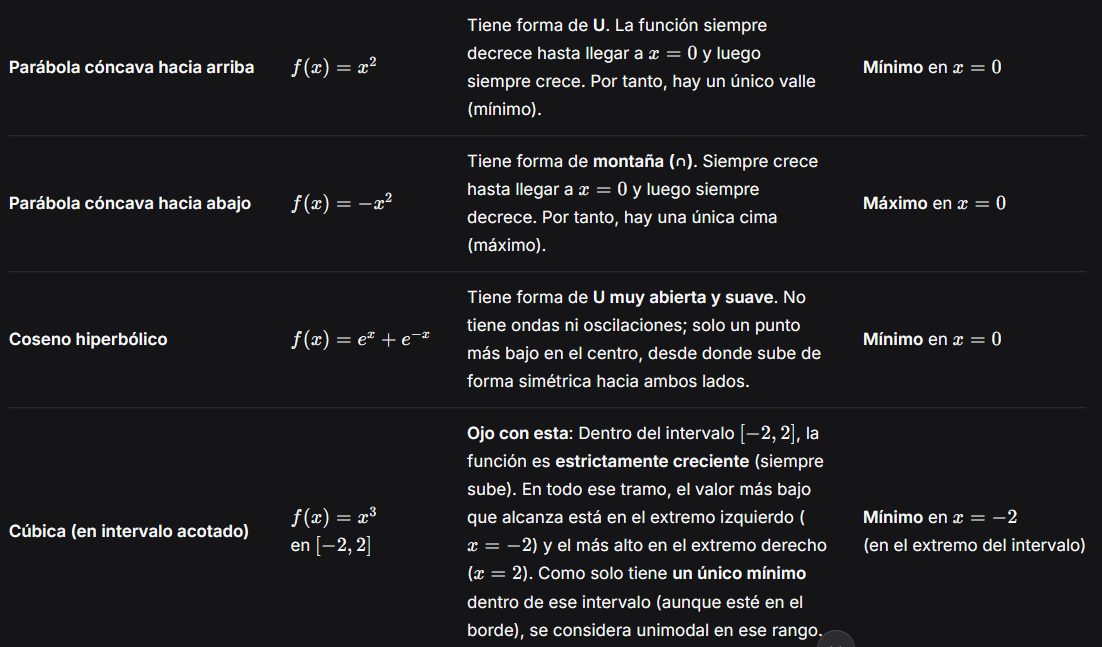

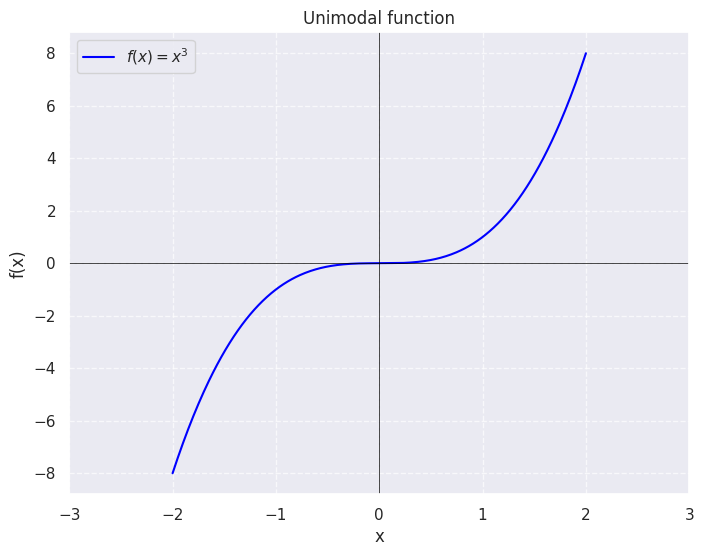

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the function f(x) = x^3
def f_unimodal(x):
    return x**3

# Define the interval for plotting the function
plot_start = -2
plot_end = 2
x_vals = np.linspace(plot_start, plot_end, 400)

# Calculate y values
y_vals = f_unimodal(x_vals)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='$f(x) = x^3$', color='blue')
plt.title('Unimodal function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Set the x-axis limits to be wider than the plotting interval
# You can change these values to make the axis extend more or less
plt.xlim(plot_start - 1, plot_end + 1) # Example: extend 1 unit on each side

plt.show()

Non unimodales funtions




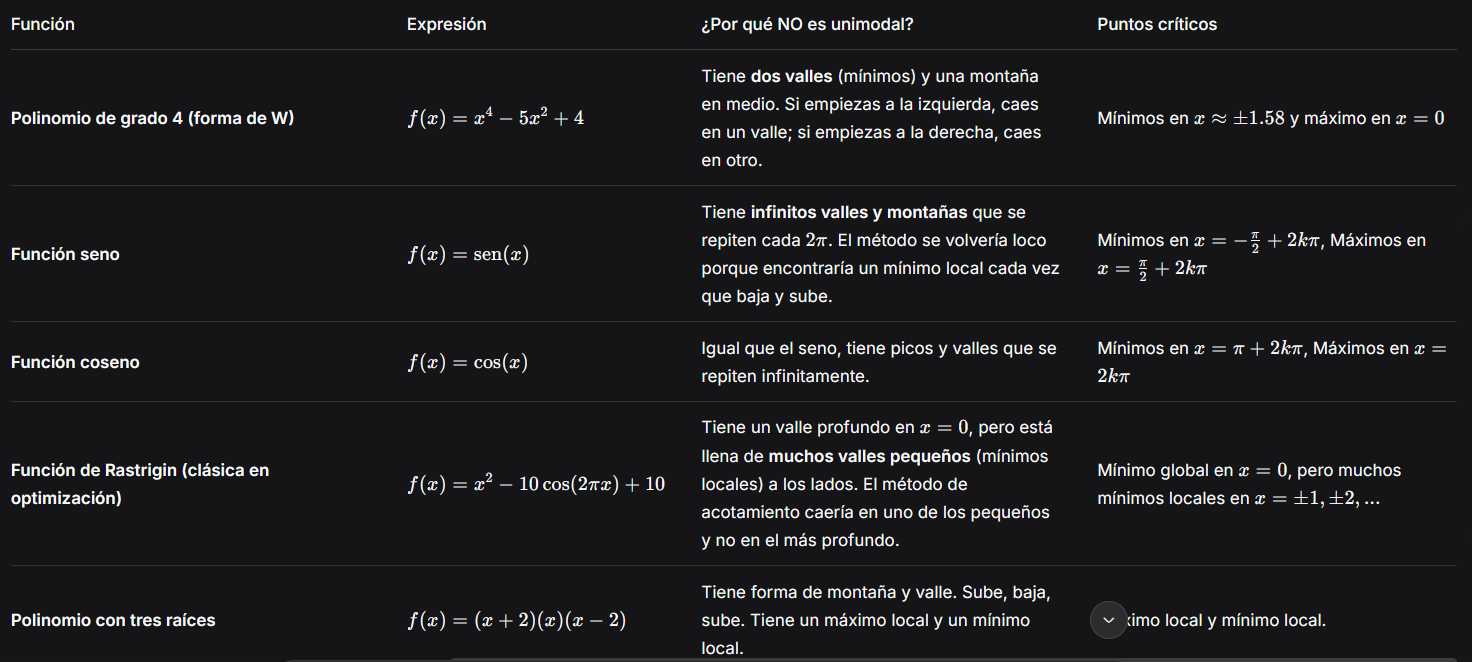

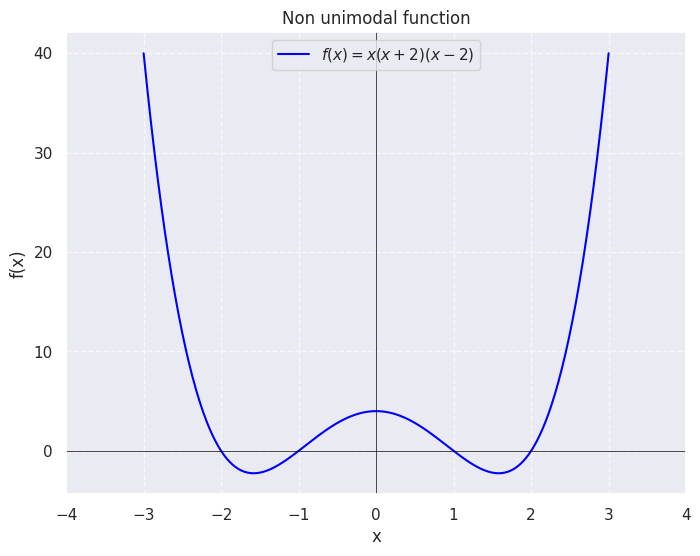

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Define the function f(x) =
def f_No_unimodal(x):
    return x**4-5*x**2+4

# Define the interval for plotting the function
plot_start = -3
plot_end = 3
x_vals = np.linspace(plot_start, plot_end, 400)

# Calculate y values
y_vals = f_No_unimodal(x_vals)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='$f(x) =x(x+2)(x-2)$', color='blue')
plt.title('Non unimodal function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Set the x-axis limits to be wider than the plotting interval
# You can change these values to make the axis extend more or less
plt.xlim(plot_start - 1, plot_end + 1) # Example: extend 1 unit on each side

plt.show()

**Bracketing**

Bracketing methods identify an interval containing the desired minimum. These methods require thus more
than one initial guess. Below are some commonly used Bracketing methods. We will try to complete the
algorithms. We will assume that the functions are unimodal, i.e. they contain a single minimum.

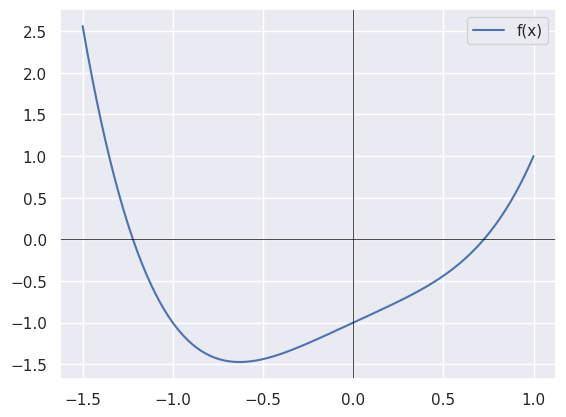

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

a_1=1
b_1=1
c_1=-1
# Our function
def fun(x):
    return a_1*x**4 + b_1*x +c_1 # Corrected indentation

# Plotting the function
fig = plt.figure()
ax = plt.axes()
x = np.linspace(-1.5, 1., 100)
ax.plot(x, fun(x), label='f(x)')
ax.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()



Brackets definition

In [ ]:
def bracket_minimum(f, x=0.0, s=1e-2, k=2.0):
    a, ya = x, f(x) # lower limit of the interval
    b, yb = x, f(x + s) # upper limit of the interval

    # Default assumes f is decreasing in 'a'; flip if not the case
    if yb > ya:
        a, b = b, a
        ya, yb = yb, ya
        s = -s # go to the left instead of right

    while True:
        c = b + s # Extend the interval
        yc = f(c)

        if yc > yb:
            # The minimum is bracketed between a and c
            return (a, c) if a < c else (c, a)

        a, ya = b, yb # Move a to b
        b, yb = c, yc # Move b to c
        s *= k # Increase the step size

# Note: The 'fun' function used here needs to be defined globally or passed as an argument.
# Assuming 'fun' from previous cells (x**4 + x - 1.0) is the intended function.
interval = bracket_minimum(fun, x=0.0, s=1e-2, k=2.0)
print("The minimum of the function is approximately in the interval : ", interval)

The minimum of the function is approximately in the interval :  (-1.27, -0.31000000000000005)


**Lagrange polynomials**

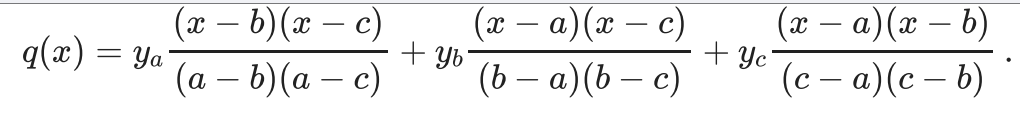

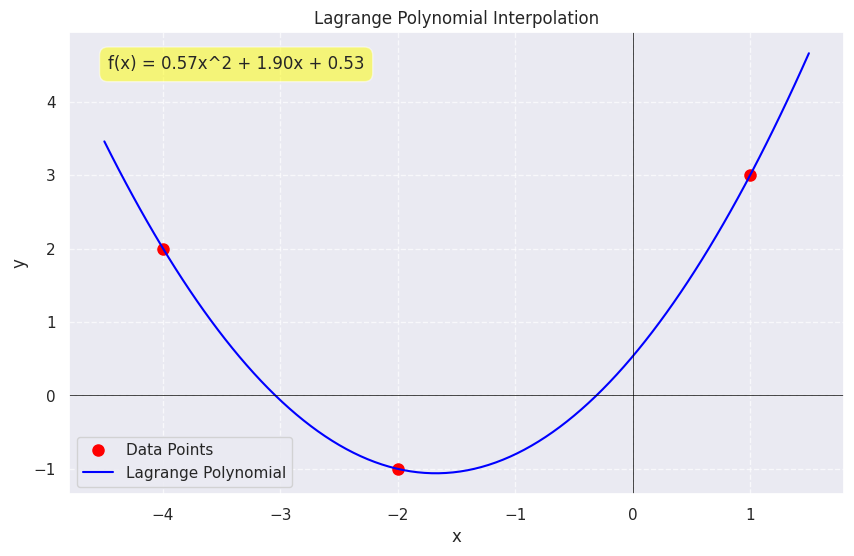

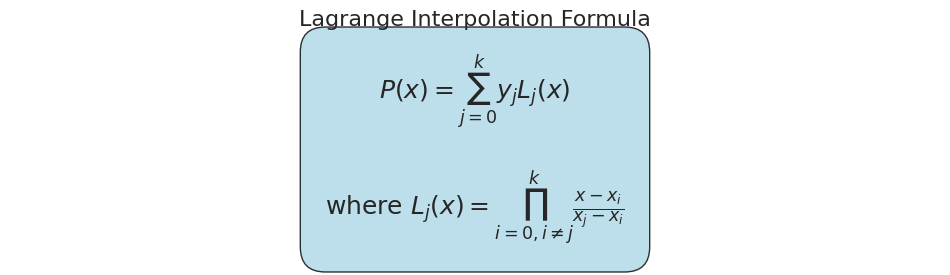

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lagrange_interpolation(x_points, y_points, x_interp):
    """
    Performs Lagrange polynomial interpolation.

    Args:
        x_points (list or np.array): x-coordinates of the data points.
        y_points (list or np.array): y-coordinates of the data points.
        x_interp (float or np.array): The x-value(s) at which to interpolate.

    Returns:
        float or np.array: The interpolated y-value(s).
    """
    n = len(x_points)

    # Ensure x_interp is an array for consistent calculations
    x_interp_arr = np.atleast_1d(x_interp)

    y_interp_arr = np.zeros_like(x_interp_arr, dtype=float)

    for i in range(n):
        # Compute the i-th Lagrange basis polynomial L_i(x)
        Li = np.ones_like(x_interp_arr, dtype=float)
        for j in range(n):
            if i != j:
                Li *= (x_interp_arr - x_points[j]) / (x_points[i] - x_points[j])
        y_interp_arr += y_points[i] * Li

    # Return a scalar if a single x_interp was provided
    if isinstance(x_interp, (float, int)) and x_interp_arr.size == 1:
        return y_interp_arr[0]
    return y_interp_arr

# --- Example Usage ---

# Data points (x, y)
x_data = np.array([ -4, -2, 1])
y_data = np.array([2, -1, 3]) # Example: y = x^2

# Points at which to interpolate and plot the polynomial
x_plot = np.linspace(min(x_data) - 0.5, max(x_data) + 0.5, 100)
y_interp_plot = lagrange_interpolation(x_data, y_data, x_plot)

# Calculate polynomial coefficients using polyfit
# The degree of the polynomial is len(x_data) - 1
coefficients = np.polyfit(x_data, y_data, len(x_data) - 1)

# Format the polynomial equation string
def format_polynomial_string(coeffs):
    terms = []
    degree = len(coeffs) - 1
    for i, c in enumerate(coeffs):
        if abs(c) < 1e-9: # Skip very small coefficients
            continue
        power = degree - i
        if power == 0: # Constant term
            terms.append(f'{c:.2f}')
        elif power == 1: # Linear term
            terms.append(f'{c:.2f}x')
        else: # Higher degree terms
            terms.append(f'{c:.2f}x^{power}')

    if not terms: # Handle cases where all coefficients are zero
        return 'f(x) = 0'

    # Join terms with appropriate signs
    poly_str = 'f(x) = ' + terms[0]
    for term in terms[1:]:
        if term.startswith('-'):
            poly_str += ' ' + term # Negative sign is already there
        else:
            poly_str += ' + ' + term
    return poly_str.replace('+ -', '- ')

polynomial_equation = format_polynomial_string(coefficients)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'o', label='Data Points', markersize=8, color='red')
plt.plot(x_plot, y_interp_plot, '-', label='Lagrange Polynomial', color='blue')

plt.title('Lagrange Polynomial Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Add the polynomial equation to the plot
plt.text(0.05, 0.95, polynomial_equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.show()

# --- Display the Lagrange Formula ----
plt.figure(figsize=(12, 3)) # Adjust size as needed
ax_formula = plt.gca()
ax_formula.set_axis_off() # Hide axes

# LaTeX string for the Lagrange Interpolation Formula
lagrange_formula_latex = r"""$P(x) = \sum_{j=0}^{k} y_j L_j(x)$

where $L_j(x) = \prod_{i=0, i \neq j}^{k} \frac{x - x_i}{x_j - x_i}$"""

# Add the formula as text to the figure
ax_formula.text(0.5, 0.5, lagrange_formula_latex, fontsize=18,
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=1", fc="lightblue", ec="black", lw=1, alpha=0.8))

plt.title('Lagrange Interpolation Formula', fontsize=16)
plt.show()

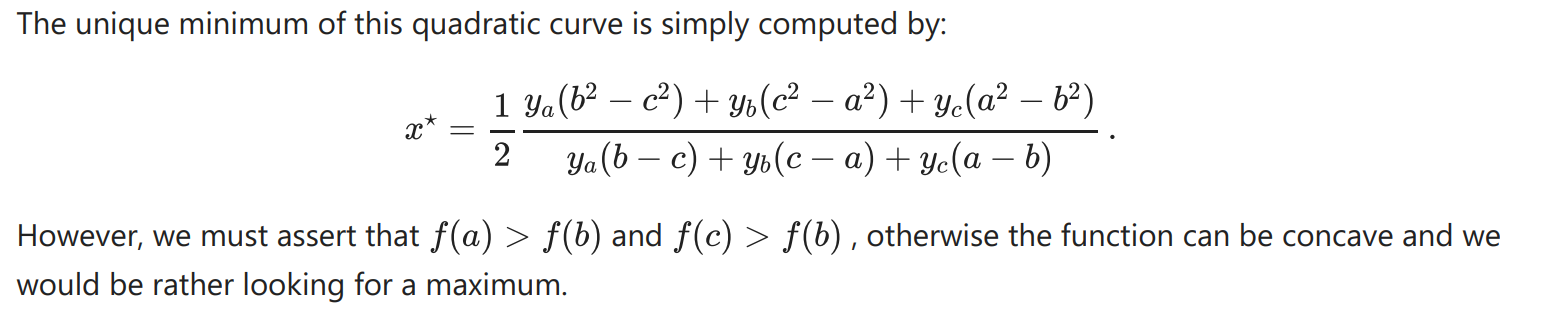

**quadratic fit search algorithm**

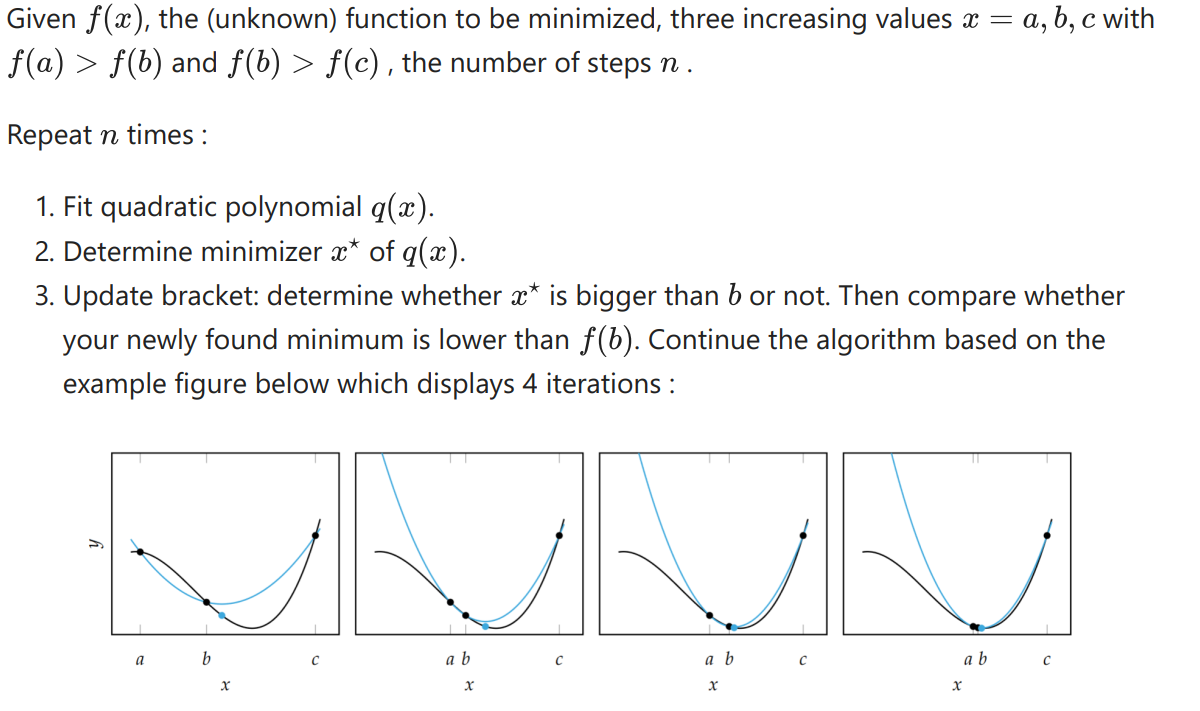


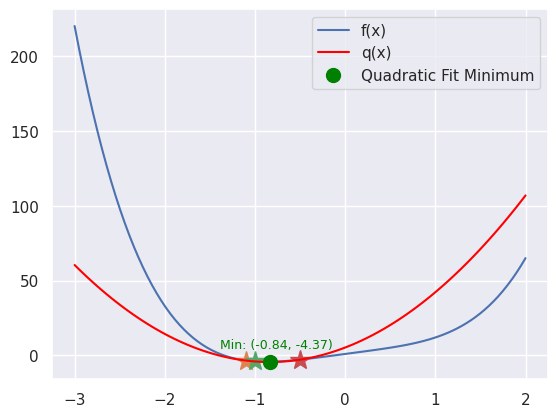

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set()

# quadratic function q(x) evaluation
def quadratic_fit(x, a, b, c, ya, yb, yc):
    assert a != b and b != c and a != c, "points must be different from each other"
    return ya * (x - b) * (x - c) / ((a - b) * (a - c)) + \
           yb * (x - a) * (x - c) / ((b - a) * (b - c)) + \
           yc * (x - a) * (x - b) / ((c - a) * (c - b))

# minimum of the quadratic function
def quadratic_fit_min(a, b, c, ya, yb, yc):
    # Formula for the x-coordinate of the minimum of a quadratic passing through three points
    numerator = ya * (b**2 - c**2) + yb * (c**2 - a**2) + yc * (a**2 - b**2)
    denominator = 2 * (ya * (b - c) + yb * (c - a) + yc * (a - b))
    if denominator == 0:
        return None # Avoid division by zero, indicates points are collinear or not a quadratic
    return numerator / denominator

def fun(x):
    return 3*x**4 + 8*x +1.0

#plotting the function
fig = plt.figure()
ax = plt.axes()
x = np.linspace(-3, 2., 100)
ax.plot(x, fun(x), label='f(x)')

a, b, c = -1.1, -1,-0.5
ya, yb, yc = fun(a), fun(b), fun(c)

ax.plot(a, ya, '*', markersize=15)
ax.plot(b, yb, '*', markersize=15)
ax.plot(c, yc, '*', markersize=15)
ax.plot(x, quadratic_fit(x, a, b, c, ya, yb, yc), color='red', label='q(x)')

# Plot the minimum of the quadratic fit
x_min_quadratic = quadratic_fit_min(a, b, c, ya, yb, yc)
if x_min_quadratic is not None:
    y_min_quadratic = quadratic_fit(x_min_quadratic, a, b, c, ya, yb, yc)
    ax.plot(x_min_quadratic, y_min_quadratic, 'o', markersize=10, color='green', label='Quadratic Fit Minimum')
    ax.annotate(f'Min: ({x_min_quadratic:.2f}, {y_min_quadratic:.2f})',
                (x_min_quadratic, y_min_quadratic), textcoords="offset points", xytext=(5,10), ha='center', fontsize=9, color='green')

ax.legend()
plt.show()

example 2

 the minimum of the function is approximately :  -0.8566667166213471


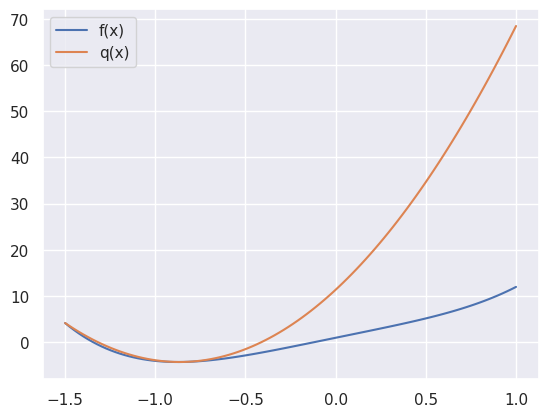

In [ ]:
#the algorithm
def quadratic_fit_search(f, a, b, c, n):
    assert a < b < c, "a, b, c not consecutive "
    assert f(a) > f(b) and f(c) > f(b), "f(b) should be less than f(a) and f(c)"
    ya, yb, yc = f(a), f(b), f(c)
    for i in range(n):
        # Use quadratic_fit_min to find the x-coordinate of the minimum of the quadratic fit
        x_min_quad = quadratic_fit_min(a, b, c, ya, yb, yc)

        # If the quadratic fit minimum is not None and within the current bracket [a, c], use it.
        # Otherwise, fall back to b or a simple bisection if needed. For this problem, we assume it's a good candidate.
        if x_min_quad is not None and a <= x_min_quad <= c:
            x = x_min_quad
        else:
            # As a fallback or if x_min_quad is outside the bracket, try a point near the current minimum 'b'
            # For simplicity, we can use 'b' or recalculate a new point.
            # Given the problem's iterative nature, a more robust check might be needed for real applications.
            # For now, let's assume quadratic_fit_min is reliable enough or use b as a safe fallback if it's bad.
            x = b # This will cause it to essentially stall if x_min_quad is problematic, but keeps it running.

        yx = f(x) # Function evaluation at the new point

        if x > b:
            if yx > yb:
                # The minimum is now in the interval [a, b, x]. So, update c and yc.
                c, yc = x, yx
            else:
                # The minimum is now in the interval [b, x, c]. So, update a, ya, b, yb.
                a, ya = b, yb
                b, yb = x, yx
        else: # x <= b
            if yx > yb:
                # The minimum is now in the interval [x, b, c]. So, update a and ya.
                a, ya = x, yx
            else:
                # The minimum is now in the interval [a, x, b]. So, update c, yc, b, yb.
                c, yc = b, yb
                b, yb = x, yx
    return a, b, c

#example
x_sol = quadratic_fit_search(fun, -1.5, -0.5, 2, 5)
print(" the minimum of the function is approximately : " ,x_sol[1] )
fig = plt.figure()
ax = plt.axes()
x = np.linspace(-1.5, 1., 100)
ax.plot(x, fun(x), label='f(x)')
a,b,c = x_sol[0], x_sol[1],x_sol[2]
ya,yb,yc =fun(a), fun(b), fun(c)
ax.plot(x, quadratic_fit(x,a,b,c,ya,yb,yc), label='q(x)')
ax.legend()

**Bisection method**

![image.png]([Media removed: image/png, ~237620 chars])

![image.png]([Media removed: image/png, ~97456 chars])

### Uso del Método de Bisección para Encontrar Máximos o Mínimos

Aunque el método de bisección se utiliza fundamentalmente para encontrar las raíces (ceros) de una función, es decir, los puntos donde $f(x) = 0$, podemos adaptarlo para encontrar los máximos o mínimos de una función continua y diferenciable.

La clave está en que los puntos donde una función alcanza un máximo o un mínimo local (extremo) son aquellos donde su primera derivada es cero ($f'(x) = 0$).

Por lo tanto, para encontrar un extremo de una función $f(x)$ utilizando el método de bisección, seguimos estos pasos:

1.  **Calcular la primera derivada** de la función, $f'(x)$.
2.  **Aplicar el método de bisección a $f'(x)$** para encontrar sus raíces. La raíz de $f'(x)$ será el valor de $x$ en el que $f(x)$ tiene un máximo o un mínimo.
3.  Una vez encontrado este valor de $x$, lo podemos **sustituir en la función original $f(x)$** para obtener el valor del máximo o mínimo.

Es importante recordar que el método de bisección requiere que la función (en este caso, la derivada $f'(x)$) cambie de signo en el intervalo inicial. Además, solo encontrará un extremo a la vez dentro de un intervalo donde $f'(x)$ sea unimodal (solo un cambio de signo).


In [ ]:
import numpy as np

def bisection_root_finding(func, a, b, tol=1e-6, max_iter=100):
    """
    Implementa el método de bisección para encontrar una raíz de una función.

    Parámetros:
    func (callable): La función para la cual se busca la raíz.
                     Debe tomar un solo argumento (x).
    a (float): El extremo inferior del intervalo inicial.
    b (float): El extremo superior del intervalo inicial.
    tol (float): La tolerancia (criterio de parada) para la aproximación de la raíz.
                 El algoritmo se detiene cuando la longitud del intervalo es menor que `tol`.
    max_iter (int): El número máximo de iteraciones.

    Retorna:
    tuple: Una tupla (raíz_aproximada, datos_iteracion) si se encuentra la raíz.
           `raíz_aproximada` es float o None.
           `datos_iteracion` es una lista de diccionarios con {'midpoint', 'f_midpoint'}.
    """

    iteration_data = [] # List to store iteration details for plotting

    # Verificar si la función cambia de signo en el intervalo inicial [a, b]
    if func(a) * func(b) >= 0:
        print("Error: La función no cambia de signo en el intervalo inicial.")
        print(f"f({a}) = {func(a)}, f({b}) = {func(b)}")
        return None, iteration_data # Return None for root, but still return empty iteration_data

    # Iterar hasta alcanzar la tolerancia o el número máximo de iteraciones
    for iteration in range(max_iter):
        midpoint = (a + b) / 2
        f_midpoint = func(midpoint)

        iteration_data.append({'midpoint': midpoint, 'f_midpoint': f_midpoint})

        # Si el punto medio es la raíz (o muy cercano), o el intervalo es suficientemente pequeño, terminamos
        if abs(f_midpoint) < tol or (b - a) / 2 < tol:
            return midpoint, iteration_data

        # Actualizar el intervalo
        if func(a) * f_midpoint < 0:
            b = midpoint
        else:
            a = midpoint

        print(f"Iteración {iteration+1}: Intervalo = [{a:.6f}, {b:.6f}], Punto medio = {midpoint:.6f}, f(Punto medio) = {f_midpoint:.6f}")

    print("Advertencia: El método de bisección alcanzó el número máximo de iteraciones sin converger.")
    return (a + b) / 2, iteration_data # Retornar la mejor aproximación encontrada y los datos de iteración

# --- Ejemplo de uso ---

# Definir una función de ejemplo: f(x) = x^3 - x - 2
def example_function(x):
    return x**3 - x - 2

# Definir el intervalo inicial [a, b]
# Sabemos que f(1) = 1 - 1 - 2 = -2 (negativo)
# y f(2) = 8 - 2 - 2 = 4 (positivo)
# Por lo tanto, una raíz debe estar entre 1 y 2.
a_val = 1
b_val = 2

# Definir la tolerancia y el número máximo de iteraciones
tolerance = 1e-6
max_iterations = 100

print(f"Buscando la raíz de f(x) = x^3 - x - 2 en el intervalo [{a_val}, {b_val}]")
root, iteration_data = bisection_root_finding(example_function, a_val, b_val, tolerance, max_iterations)

if root is not None:
    print(f"\nLa raíz aproximada es: {root:.6f}")
    print(f"Valor de la función en la raíz aproximada: f({root:.6f}) = {example_function(root):.6f}")


Buscando la raíz de f(x) = x^3 - x - 2 en el intervalo [1, 2]
Iteración 1: Intervalo = [1.500000, 2.000000], Punto medio = 1.500000, f(Punto medio) = -0.125000
Iteración 2: Intervalo = [1.500000, 1.750000], Punto medio = 1.750000, f(Punto medio) = 1.609375
Iteración 3: Intervalo = [1.500000, 1.625000], Punto medio = 1.625000, f(Punto medio) = 0.666016
Iteración 4: Intervalo = [1.500000, 1.562500], Punto medio = 1.562500, f(Punto medio) = 0.252197
Iteración 5: Intervalo = [1.500000, 1.531250], Punto medio = 1.531250, f(Punto medio) = 0.059113
Iteración 6: Intervalo = [1.515625, 1.531250], Punto medio = 1.515625, f(Punto medio) = -0.034054
Iteración 7: Intervalo = [1.515625, 1.523438], Punto medio = 1.523438, f(Punto medio) = 0.012250
Iteración 8: Intervalo = [1.519531, 1.523438], Punto medio = 1.519531, f(Punto medio) = -0.010971
Iteración 9: Intervalo = [1.519531, 1.521484], Punto medio = 1.521484, f(Punto medio) = 0.000622
Iteración 10: Intervalo = [1.520508, 1.521484], Punto medio = 

**Exercises**


Buscando el punto crítico (donde f'(x) = 0) para f(x) = x^(1/x) en el intervalo [2.0, 4.0]
Iteración 1: Intervalo = [2.000000, 3.000000], Punto medio = 3.000000, f(Punto medio) = -0.015803
Iteración 2: Intervalo = [2.500000, 3.000000], Punto medio = 2.500000, f(Punto medio) = 0.019323
Iteración 3: Intervalo = [2.500000, 2.750000], Punto medio = 2.750000, f(Punto medio) = -0.002216
Iteración 4: Intervalo = [2.625000, 2.750000], Punto medio = 2.625000, f(Punto medio) = 0.007319
Iteración 5: Intervalo = [2.687500, 2.750000], Punto medio = 2.687500, f(Punto medio) = 0.002278
Iteración 6: Intervalo = [2.687500, 2.718750], Punto medio = 2.718750, f(Punto medio) = -0.000034
Iteración 7: Intervalo = [2.703125, 2.718750], Punto medio = 2.703125, f(Punto medio) = 0.001106
Iteración 8: Intervalo = [2.710938, 2.718750], Punto medio = 2.710938, f(Punto medio) = 0.000532
Iteración 9: Intervalo = [2.714844, 2.718750], Punto medio = 2.714844, f(Punto medio) = 0.000248
Iteración 10: Intervalo = [2.7167

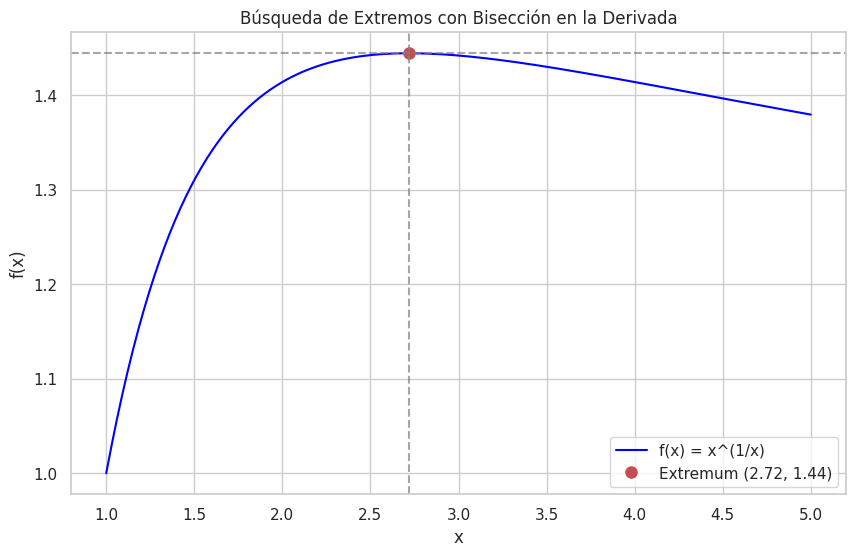

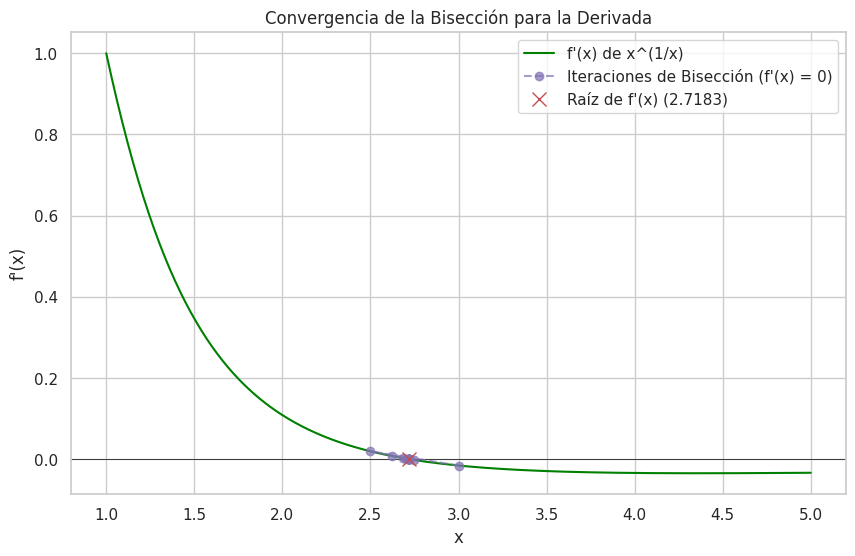

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')

# Nuestra función para la cual queremos encontrar el extremum (mínimo en este caso)
def fun_to_optimize(x):
    return x**(1/x)

# Su primera derivada (correcta para f(x) = x^(1/x))
def fun_to_optimize_derivative(x):
    # Derivative of x^(1/x) is x^(1/x) * (1 - ln(x)) / x^2
    # Use np.log for array compatibility. Ensure x > 0 for np.log(x).
    # The x_plot array is already filtered to be > 0, and bisection passes scalars > 0, so no explicit check needed here.
    return fun_to_optimize(x) * (1 - np.log(x)) / (x**2)

# --- Parámetros para el método de bisección en la derivada ---
# Necesitamos encontrar un intervalo [a, b] donde la derivada cambie de signo.
# El extremum de x^(1/x) es en x = e (aprox. 2.718)
# fun_to_optimize_derivative(2) > 0
# fun_to_optimize_derivative(4) < 0
# Así, la raíz de la derivada (y por lo tanto el extremum de la función original)
# está entre 2 y 4.
a_prime = 2.0
b_prime = 4.0
tolerance = 1e-6
max_iterations = 100

print(f"Buscando el punto crítico (donde f'(x) = 0) para f(x) = x^(1/x) en el intervalo [{a_prime}, {b_prime}]")

# Usamos la función bisection_root_finding (definida anteriormente) en la derivada
x_extremum, derivative_iteration_data = bisection_root_finding(fun_to_optimize_derivative, a_prime, b_prime, tolerance, max_iterations)

if x_extremum is not None:
    y_extremum = fun_to_optimize(x_extremum)
    print(f"\nEl valor de x para el extremum aproximado es: {x_extremum:.6f}")
    print(f"El valor de la función en el extremum aproximado es: f({x_extremum:.6f}) = {y_extremum:.6f}")

    # --- Gráfico de la función original y el extremum ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Trazar la función original
    x_plot = np.linspace(a_prime - 1, b_prime + 1, 400) # Ajustar el rango de trazado según sea necesario
    x_plot = x_plot[x_plot > 0] # Ensure x > 0 for x^(1/x)
    ax.plot(x_plot, fun_to_optimize(x_plot), label='f(x) = x^(1/x)', color='blue')

    # Marcar el extremum encontrado
    ax.plot(x_extremum, y_extremum, 'ro', markersize=8, label=f'Extremum ({x_extremum:.2f}, {y_extremum:.2f})')
    ax.axvline(x_extremum, color='gray', linestyle='--', alpha=0.7)
    ax.axhline(y_extremum, color='gray', linestyle='--', alpha=0.7)

    ax.set_title('Búsqueda de Extremos con Bisección en la Derivada')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    plt.show()

    # --- Gráfico de la derivada y su raíz (convergencia de la bisección) ---
    fig_deriv, ax_deriv = plt.subplots(figsize=(10, 6))

    # Trazar la función derivada
    ax_deriv.plot(x_plot, fun_to_optimize_derivative(x_plot), label="f'(x) de x^(1/x)", color='green')
    ax_deriv.axhline(0, color='black', linewidth=0.5) # Eje x para la derivada

    # Trazar las iteraciones para la raíz de la derivada
    deriv_midpoints_x = [d['midpoint'] for d in derivative_iteration_data]
    deriv_midpoints_y = [d['f_midpoint'] for d in derivative_iteration_data]

    ax_deriv.plot(deriv_midpoints_x, deriv_midpoints_y, 'm--o', markersize=6, alpha=0.7, label="Iteraciones de Bisección (f'(x) = 0)")
    ax_deriv.plot(x_extremum, 0, 'rx', markersize=10, label=f"Raíz de f'(x) ({x_extremum:.4f})")


    ax_deriv.set_title('Convergencia de la Bisección para la Derivada')
    ax_deriv.set_xlabel('x')
    ax_deriv.set_ylabel("f'(x)")
    ax_deriv.legend()
    plt.show()

else:
    print("No se pudo encontrar un extremum en el intervalo dado o la bisección no convergió.")

exercise 2

In [ ]:
# Instalar SymPy si aún no está instalado
!pip install sympy

Aquí te mostramos cómo puedes definir una función simbólica, calcular su derivada y luego convertir esa derivada en una función Python callable.

Función original simbólica: 1.2*x/(x + 10) + 0.02
Primera derivada simbólica: -1.2*x/(x + 10)**2 + 1.2/(x + 10)

Evaluando la derivada en x = 1.0:
f'(1.0) = 0.09917355371900827

Valores de x: [-2.         -1.55555556 -1.11111111 -0.66666667 -0.22222222  0.22222222
  0.66666667  1.11111111  1.55555556  2.        ]
Valores de la derivada: [0.1875     0.16828255 0.151875   0.1377551  0.12551653 0.11483932
 0.10546875 0.0972     0.08986686 0.08333333]


<lambdifygenerated-5>:2: RuntimeWarning: divide by zero encountered in divide
  return -1.2*x/(x + 10)**2 + 1.2/(x + 10)


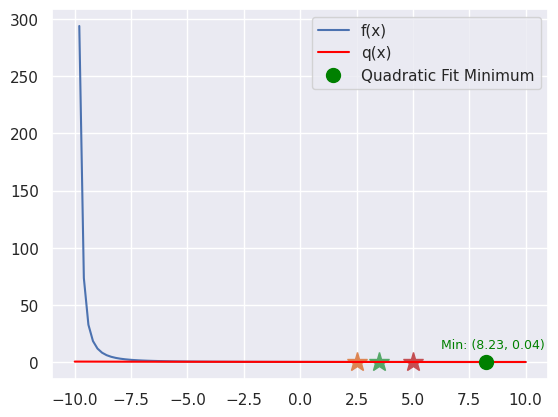

In [ ]:
from sympy import symbols, diff, lambdify
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

# quadratic function q(x) evaluation
def quadratic_fit(x, a, b, c, ya, yb, yc):
    assert a != b and b != c and a != c, "points must be different from each other"
    return ya * (x - b) * (x - c) / ((a - b) * (a - c)) + \
           yb * (x - a) * (x - c) / ((b - a) * (b - c)) + \
           yc * (x - a) * (x - b) / ((c - a) * (c - b))

# minimum of the quadratic function
def quadratic_fit_min(a, b, c, ya, yb, yc):
    # Formula for the x-coordinate of the minimum of a quadratic passing through three points
    numerator = ya * (b**2 - c**2) + yb * (c**2 - a**2) + yc * (a**2 - b**2)
    denominator = 2 * (ya * (b - c) + yb * (c - a) + yc * (a - b))
    if denominator == 0:
        return None # Avoid division by zero, indicates points are collinear or not a quadratic
    return numerator / denominator

# 1. Definir el símbolo para la variable independiente
x = symbols('x')

# 2. Definir la función original simbólicamente
#    Usaremos la función f(x) = x^4 + x - 1.0 del ejemplo anterior
original_symbolic_func =0.02+1.2*(x/(10+x))

print(f"Función original simbólica: {original_symbolic_func}")

# 3. Calcular la primera derivada de la función con respecto a 'x'
derivative_symbolic_func = diff(original_symbolic_func, x)

print(f"Primera derivada simbólica: {derivative_symbolic_func}")

# 4. Convertir la función derivada simbólica en una función Python callable
#    Esto nos permite evaluar la derivada para valores numéricos de x
derivative_python_func = lambdify(x, derivative_symbolic_func, 'numpy')

# --- Ejemplo de uso de la función derivada generada ---
# Evaluar la derivada en un punto, por ejemplo, x = 1
example_x_value = 1.0
derivative_at_example_x = derivative_python_func(example_x_value)

print(f"\nEvaluando la derivada en x = {example_x_value}:")
print(f"f'({example_x_value}) = {derivative_at_example_x}")

# Puedes usar 'derivative_python_func' ahora en tus algoritmos numéricos
# Por ejemplo, para un rango de valores:
x_values = np.linspace(-2, 2, 10)
y_derivative_values = derivative_python_func(x_values)
print(f"\nValores de x: {x_values}")
print(f"Valores de la derivada: {y_derivative_values}")

#plotting the function
fig = plt.figure()
ax = plt.axes()
x = np.linspace(-10, 10, 100)
ax.plot(x, derivative_python_func(x), label='f(x)')


a, b, c = 2.5, 3.5, 5
ya, yb, yc = derivative_python_func(a), derivative_python_func(b), derivative_python_func(c)

ax.plot(a, ya, '*', markersize=15)
ax.plot(b, yb, '*', markersize=15)
ax.plot(c, yc, '*', markersize=15)
ax.plot(x, quadratic_fit(x, a, b, c, ya, yb, yc), color='red', label='q(x)')

# Plot the minimum of the quadratic fit
x_min_quadratic = quadratic_fit_min(a, b, c, ya, yb, yc)
if x_min_quadratic is not None:
    y_min_quadratic = quadratic_fit(x_min_quadratic, a, b, c, ya, yb, yc)
    ax.plot(x_min_quadratic, y_min_quadratic, 'o', markersize=10, color='green', label='Quadratic Fit Minimum')
    ax.annotate(f'Min: ({x_min_quadratic:.2f}, {y_min_quadratic:.2f})',
                (x_min_quadratic, y_min_quadratic), textcoords="offset points", xytext=(5,10), ha='center', fontsize=9, color='green')

ax.legend()
plt.show()


